In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [10]:
dataset = load_dataset("Deysi/spam-detection-dataset")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8175
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2725
    })
})

# Data Analysis

In [50]:
train_data = pd.DataFrame(dataset["train"])
test_data = pd.DataFrame(dataset["test"])
train_data.head()

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam


In [13]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8175 entries, 0 to 8174
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8175 non-null   object
 1   label   8175 non-null   object
dtypes: object(2)
memory usage: 127.9+ KB


<Figure size 600x400 with 0 Axes>

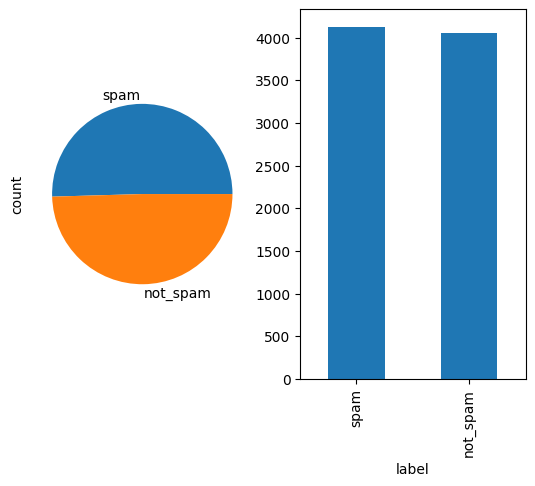

In [19]:
plt.figure(figsize=(6, 4))
fig, axs = plt.subplots(1, 2)
train_data["label"].value_counts().plot(kind="pie", ax=axs[0])
train_data["label"].value_counts().plot(kind="bar", ax=axs[1])
plt.show()

In [24]:
df = train_data.copy()
df.head()

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam


# Data Preprocessing

In [27]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [30]:
def temizle_ve_lemmatize_et(metin):
    metin = metin.lower()

    tokenlar = word_tokenize(metin)

    temiz_tokenlar = [
        lemmatizer.lemmatize(token)
        for token in tokenlar
        if token.isalnum() and token not in stop_words
    ]

    return " ".join(temiz_tokenlar)

df["temiz_text"] = df["text"].apply(temizle_ve_lemmatize_et)
df["temiz_text"].head()

,temiz_text
0,hey looking xray baggage datasets provide
1,get rich quick make million day new revolution...
2,urgent message wo believe offer hey yeah eye r...
3,google ai blog contributing data deepfake dete...
4,trying see anyone already timestamps key event...


In [46]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english", min_df=0.03, max_df=0.97)

In [47]:
X_train_vectorized = tfidf_vectorizer.fit_transform(df["temiz_text"])

# matrix vis
normal_matrix = X_train_vectorized.toarray()
words = tfidf_vectorizer.get_feature_names_out()
tfidf_table = pd.DataFrame(data=normal_matrix, columns=words)
tfidf_table.head()

,able,access,advance,algorithm,amazing,amp,analysis,appreciated,attention,available,...,website,week,weight,win,wo,work,working,world,x200b,year
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.258771,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.199966,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [51]:
X_test, y_test = test_data["text"], test_data["label"]
X_test_vectorized = tfidf_vectorizer.transform(X_test)

# matrix vis
normal_matrix = X_test_vectorized.toarray()
words = tfidf_vectorizer.get_feature_names_out()
tfidf_table = pd.DataFrame(data=normal_matrix, columns=words)
tfidf_table.head()

,able,access,advance,algorithm,amazing,amp,analysis,appreciated,attention,available,...,website,week,weight,win,wo,work,working,world,x200b,year
0,0.0,0.0,0.0,0.0,0.0,0.566605,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.411501,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.245592,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.237231
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.313312,0.308567,0.0,0.000000,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000


# ML Model Build

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [52]:
model = LogisticRegression()
model.fit(X_train_vectorized, df["label"])

LogisticRegression()

In [54]:
y_pred = model.predict(X_test_vectorized)
accuracy_score(y_test, y_pred)

0.9878899082568807

[[1339   11]
 [  22 1353]]


<Axes: >

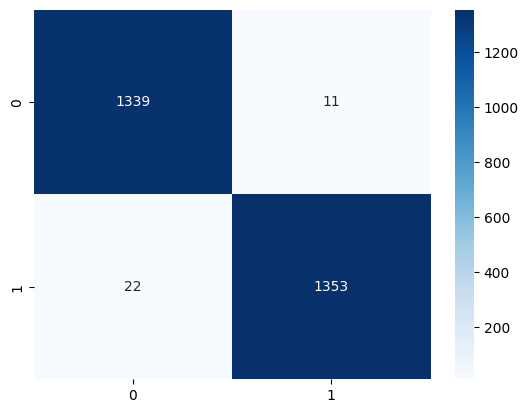

In [59]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")